In [2]:
import time
import warnings
from typing import Any, Dict, List, Optional, Tuple, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skew, kurtosis
from scipy.interpolate import RectBivariateSpline
from IPython.display import display_html
from heston import HestonParameters

from heston import (
    AnalyticalVarianceSwapPricer,
    BlackScholesPricer,
    HestonCalibrationConfig,
    HestonCalibrator,
    HestonParameters,
    HestonPricer,
    HestonSimulator,
    HestonSimulatorFT,
    HestonSimulatorQE,
    ImpliedVolatilitySolver,
    PriceCorrection,
)

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10.5,
    'axes.titlesize': 11.5,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (7.0, 4.2),      
    'figure.dpi': 140,                  
    'figure.autolayout': True,         
    'lines.linewidth': 1.8,            
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
})

In [3]:
v_0 = 0.09
base_params = HestonParameters(
    kappa=1.70,
    theta=0.04,
    xi=0.60,
    rho=-0.70,
    v_0=v_0
)

print(f"Feller Ratio: {base_params.feller_ratio:.4f}; Condition Satisfied: {base_params.is_feller_satisfied}")
display(base_params.summary())

Feller Ratio: 0.3778; Condition Satisfied: False


,Parameter,Symbol,Value
0,Mean Reversion Speed (kappa),κ,1.70
1,Long-Term Variance (theta),θ,0.04
2,Vol of Vol (xi),ξ,0.60
3,Asset-Variance Correlation (rho),ρ,-0.70
4,Initial Variance (v_0),v₀,0.09


In [4]:
S0 = 120.0
K = 120.0
T = 1.0
r = 0.02
q = 0
n_steps = 252
n_sims = 100_000

market_inputs_sim = {
    "S0": S0,
    "T": T,
    "r": r,
    "n_steps":n_steps,
    "n_sims":n_sims
}

# Gauss-Legendre Quadrature
pricer = HestonPricer(n_quad_points=64, u_max=120.0)
c_fast = pricer.price_options_fast(S0, K, T, r, base_params, "call")
p_fast = pricer.price_options_fast(S0, K, T, r, base_params, "put")

print(f"Market Params: S0={S0}, K={K}, T={T}")
print(f"Pricer initialized; Vanilla Call = {c_fast:.4f} and Put = {p_fast:.4f}")

Market Params: S0=120.0, K=120.0, T=1.0
Pricer initialized; Vanilla Call = 12.0277 and Put = 9.6516


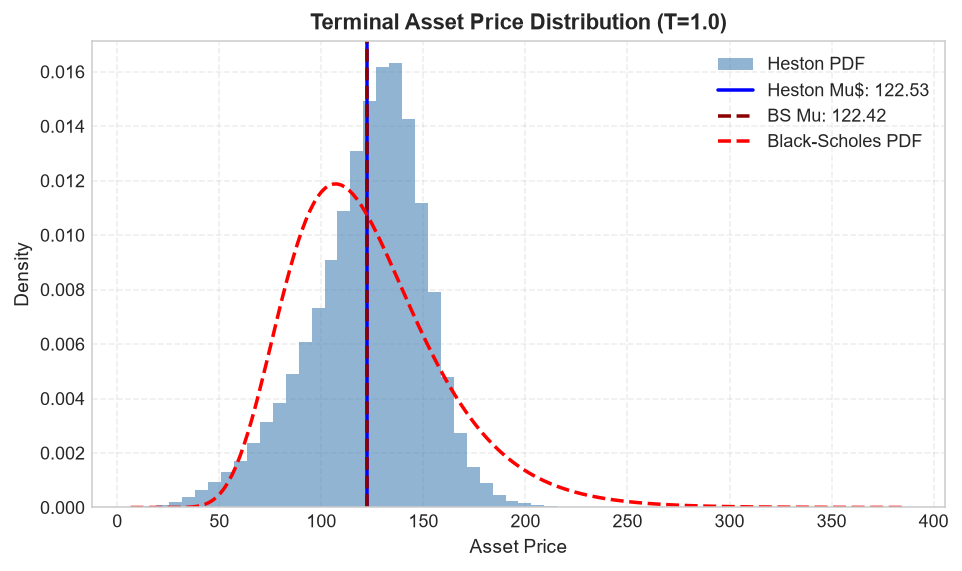

In [5]:
sim = HestonSimulator(base_params)
t_grid, S_paths, v_paths = sim.simulate_paths(**market_inputs_sim)

S_T = S_paths[:, -1]
S_T_returns = np.log(S_T / market_inputs_sim['S0'])
forward_ST = np.mean(S_T)
Df = np.exp(-r * T)

plt.figure()
plt.hist(S_T, bins=60, density=True, alpha=0.6, color='steelblue', label='Heston PDF')
x_grid = np.linspace(S_T.min(), S_T.max(), 200)

# BS equivalent Normal PDF
bs_std = np.sqrt(v_0) * np.sqrt(T)
bs_mu = S0 * np.exp(r * T)
bs_pdf = norm.pdf(np.log(x_grid / S0), loc=(r - 0.5 * v_0) * T, scale=bs_std) / x_grid

plt.axvline(forward_ST, color='blue', linestyle='-', linewidth=1.8,
            label=f'Heston Mu$: {forward_ST:.2f}')
plt.axvline(bs_mu, color='darkred', linestyle='--', linewidth=1.8,
            label=f'BS Mu: {bs_mu:.2f}')

plt.plot(x_grid, bs_pdf, 'r--', label='Black-Scholes PDF')
plt.title(f"Terminal Asset Price Distribution (T={T})")
plt.xlabel("Asset Price")
plt.ylabel("Density")
plt.legend()
plt.show()

In [6]:
c_payoffs = np.maximum(S_T - K, 0.0)
c_mc_base = np.mean(c_payoffs) * Df
mc_call_std = np.std(c_payoffs) / np.sqrt(n_sims) * Df

p_payoffs = np.maximum(K - S_T, 0.0)
p_mc_base = np.mean(p_payoffs) * Df
mc_put_std = np.std(p_payoffs) / np.sqrt(n_sims) * Df

df_mc = pd.DataFrame({
    "Analytical Price": [c_fast, p_fast],
    "MC Price":         [c_mc_base, p_mc_base],
    "MC Error":         [abs(c_fast - c_mc_base), abs(p_fast - p_mc_base)],
    "MC Std Error":     [mc_call_std, mc_put_std]
}, index=["Call", "Put"])

print("--- Monte Carlo vs Analytical Vanilla Option Pricing Convergence ---")
display(df_mc.round(4))

--- Monte Carlo vs Analytical Vanilla Option Pricing Convergence ---


,Analytical Price,MC Price,MC Error,MC Std Error
Call,12.0277,12.1804,0.1526,0.0478
Put,9.6516,9.7035,0.0519,0.0541


In [7]:
c_result = pricer.price_and_greeks_fast(S0, K, T, r, base_params, "call")
p_result = pricer.price_and_greeks_fast(S0, K, T, r, base_params, "put")

df_greeks_analytical = pd.DataFrame({
    "Price": [c_result.price, p_result.price],
    "Delta": [c_result.delta, p_result.delta],
    "Gamma": [c_result.gamma, p_result.gamma],
    "Rho":   [c_result.rho, p_result.rho],
    "Theta": [c_result.theta, p_result.theta],
    "Vega":  [c_result.vega, p_result.vega]
}, index=["Call", "Put"])

print("\n--- Analytical Greeks (Heston) ---")
display(df_greeks_analytical.round(6))

dS = S0 * 0.01
S_T_up = S_T * (1.0 + dS / S0)
S_T_dn = S_T * (1.0 - dS / S0)

c_mc_up = np.mean(np.maximum(S_T_up - K, 0.0)) * Df
c_mc_dn = np.mean(np.maximum(S_T_dn - K, 0.0)) * Df
p_mc_up = np.mean(np.maximum(K - S_T_up, 0.0)) * Df
p_mc_dn = np.mean(np.maximum(K - S_T_dn, 0.0)) * Df

dr = 0.00005
c_mc_rup = np.mean(np.maximum(S_T * np.exp(dr * T) - K, 0.0)) * np.exp(-(r + dr) * T)
c_mc_rdn = np.mean(np.maximum(S_T * np.exp(-dr * T) - K, 0.0)) * np.exp(-(r - dr) * T)
p_mc_rup = np.mean(np.maximum(K - S_T * np.exp(dr * T), 0.0)) * np.exp(-(r + dr) * T)
p_mc_rdn = np.mean(np.maximum(K - S_T * np.exp(-dr * T), 0.0)) * np.exp(-(r - dr) * T)

dv = 0.00005
bumped_params = HestonParameters(
    kappa=base_params.kappa, 
    theta=base_params.theta, 
    xi=base_params.xi,
    rho=base_params.rho, 
    v_0=base_params.v_0 + dv
)

sim_bumped = HestonSimulator(bumped_params)
_, S_paths_bumped, _ = sim_bumped.simulate_paths(**market_inputs_sim)
S_T_vega_up = S_paths_bumped[:, -1]

c_mc_vega_up = np.mean(np.maximum(S_T_vega_up - K, 0.0)) * Df
p_mc_vega_up = np.mean(np.maximum(K - S_T_vega_up, 0.0)) * Df

vega_mc_call = (c_mc_vega_up - c_mc_base) / dv
vega_mc_put  = (p_mc_vega_up - p_mc_base) / dv

dt = T / n_steps
S_T_minus_dt = S_paths[:, -2]
Df_minus_dt = np.exp(-r * (T - dt))

c_mc_T_minus_dt = np.mean(np.maximum(S_T_minus_dt - K, 0.0)) * Df_minus_dt
p_mc_T_minus_dt = np.mean(np.maximum(K - S_T_minus_dt, 0.0)) * Df_minus_dt

theta_annual_call = (c_mc_T_minus_dt - c_mc_base) / dt
theta_annual_put  = (p_mc_T_minus_dt - p_mc_base) / dt

theta_mc_call = theta_annual_call / 365.0
theta_mc_put  = theta_annual_put / 365.0

df_greeks_mc = pd.DataFrame({
    "Price": [c_mc_base, p_mc_base],
    "Delta": [(c_mc_up - c_mc_dn) / (2 * dS), (p_mc_up - p_mc_dn) / (2 * dS)],
    "Gamma": [(c_mc_up - 2 * c_mc_base + c_mc_dn) / (dS**2), (p_mc_up - 2 * p_mc_base + p_mc_dn) / (dS**2)],
    "Rho":   [(c_mc_rup - c_mc_rdn) / (2 * dr), (p_mc_rup - p_mc_rdn) / (2 * dr)],
    "Theta": [theta_mc_call, theta_mc_put],
    "Vega":  [vega_mc_call, vega_mc_put]
}, index=["Call", "Put"])

print("\n--- Monte Carlo Greeks (Heston using Bump & Reprice) ---")
display(df_greeks_mc.round(6))

c_result_bs = BlackScholesPricer.price_and_greeks(S0, K, T, r, base_params.v_0, 'call')
p_result_bs = BlackScholesPricer.price_and_greeks(S0, K, T, r, base_params.v_0, 'put')

df_greeks_analytical = pd.DataFrame({
    "Price": [c_result_bs.price, p_result_bs.price],
    "Delta": [c_result_bs.delta, p_result_bs.delta],
    "Gamma": [c_result_bs.gamma, p_result_bs.gamma],
    "Rho":   [c_result_bs.rho, p_result_bs.rho],
    "Theta": [c_result_bs.theta, p_result_bs.theta],
    "Vega":  [c_result_bs.vega, p_result_bs.vega]
}, index=["Call", "Put"])

print("\n--- Analytical Greeks (BS) ---")
display(df_greeks_analytical.round(6))


--- Analytical Greeks (Heston) ---


,Price,Delta,Gamma,Rho,Theta,Vega
Call,12.027745,0.680689,0.013656,69.654981,-0.013578,43.401887
Put,9.651586,-0.319311,0.013656,-47.968860,-0.007133,43.401887



--- Monte Carlo Greeks (Heston using Bump & Reprice) ---


,Price,Delta,Gamma,Rho,Theta,Vega
Call,12.180358,0.679114,0.01368,69.345927,-0.013397,42.700574
Put,9.703519,-0.321725,0.01368,-48.277914,-0.006110,42.025733



--- Analytical Greeks (BS) ---


,Price,Delta,Gamma,Rho,Theta,Vega
Call,5.557349,0.605351,0.035643,67.084767,-3.420424,46.193974
Put,3.181189,-0.394649,0.035643,-50.539073,-1.067947,46.193974


In [8]:
# Put Call Parity Check
parity_target = S0 - K * np.exp(-r * T)

sim_ems = HestonSimulatorFT(base_params)
_, S_paths_ems, _ = sim_ems.simulate_paths(**market_inputs_sim, price_correction=PriceCorrection.EMS)
S_T_ems = S_paths_ems[:, -1]

c_mc_ems = np.mean(np.maximum(S_T_ems - K, 0.0)) * Df
p_mc_ems = np.mean(np.maximum(K - S_T_ems, 0.0)) * Df


sim_qe = HestonSimulatorQE(base_params)
_, S_paths_andersen, _ = sim_qe.simulate_paths(**market_inputs_sim, price_correction=PriceCorrection.ANDERSEN)
S_T_andersen = S_paths_andersen[:, -1]

c_mc_andersen = np.mean(np.maximum(S_T_andersen - K, 0.0)) * Df
p_mc_andersen = np.mean(np.maximum(K - S_T_andersen, 0.0)) * Df

df_parity = pd.DataFrame({
    "Call": [c_result.price, c_mc_base, c_mc_ems, c_mc_andersen, c_result_bs.price],
    "Put":  [p_result.price, p_mc_base, p_mc_ems, p_mc_andersen, p_result_bs.price]
}, index=[
    "Heston Analytical", 
    "Heston MC (FT None)", 
    "Heston MC (FT EMS)", 
    "Heston MC (QE Andersen)", 
    "Black-Scholes Analytical"
])

df_parity["C - P"] = df_parity["Call"] - df_parity["Put"]
df_parity["Target"] = parity_target
df_parity["Parity Error"] = df_parity["C - P"] - df_parity["Target"]

print("\n--- Put-Call Parity Check ---")
display(df_parity.round(6))


--- Put-Call Parity Check ---


,Call,Put,C - P,Target,Parity Error
Heston Analytical,12.027745,9.651586,2.376159,2.376159,0.000000
Heston MC (FT None),12.180358,9.703519,2.476839,2.376159,0.100680
Heston MC (FT EMS),12.112086,9.735926,2.376159,2.376159,-0.000000
Heston MC (QE Andersen),11.932602,9.725950,2.206652,2.376159,-0.169507
Black-Scholes Analytical,5.557349,3.181189,2.376159,2.376159,-0.000000


-------------------------------------------------Asian Call Option-------------------------------------------------
Scheme                       | Price    | Delta    | Gamma      | Vega     | Vega Std | True SE  | Naive SE
-------------------------------------------------------------------------------------------------------------------
Heston FT (None)             | 7.6188   | 0.6239   | 0.021035   | 34.0391  | 1.1032   | 0.1334   | 0.1356  
Heston QE (EMS)              | 7.5912   | 0.6258   | 0.021618   | 34.4584  | 0.4717   | 0.0903   | 0.1342  
Heston QE (Andersen M-Corr)  | 7.6181   | 0.6270   | 0.021500   | 34.6572  | 0.9500   | 0.1125   | 0.1345  
-------------------------------------------------------------------------------------------------------------------


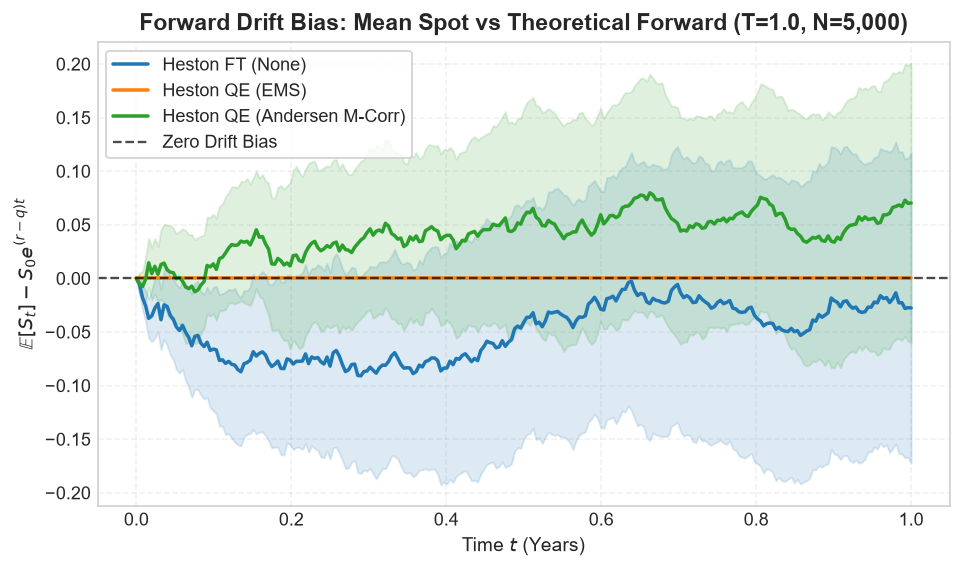

In [9]:
# Martingale Correction EMS vs QE setting
n_sims = 5_000
dv = 0.005
n_seeds = 30
start_seed = 42

schemes = [
    ('Heston FT (None)', HestonSimulatorFT, PriceCorrection.NONE),
    ('Heston QE (EMS)', HestonSimulatorQE, PriceCorrection.EMS),
    ('Heston QE (Andersen M-Corr)', HestonSimulatorQE, PriceCorrection.ANDERSEN)
]

def asian_price(S_paths):
    S_avg = np.mean(S_paths[:, 1:], axis=1)
    return np.maximum(S_avg - K, 0.0) * np.exp(-r * T)

theoretical_fwd = S0 * np.exp((r - q) * np.linspace(0.0, T, n_steps + 1))
results = {}
drift_biases = {}
drift_biases_se = {} 
for name, sim_cls, corr in schemes:
    prices, deltas, gammas, vegas, naive_ses = [], [], [], [], []
    seed_drift_biases = []
    
    for i in range(n_seeds):
        current_seed = start_seed + i
        
        # Base simulation
        sim_base = sim_cls(base_params, seed=current_seed)
        time_grid, S_base, _ = sim_base.simulate_paths(
            S0, T, r, n_steps=n_steps, n_sims=n_sims, q=q, price_correction=corr
        )
        payoffs = asian_price(S_base)
        p_base = payoffs.mean()
        prices.append(p_base)
        naive_ses.append(payoffs.std(ddof=1) / np.sqrt(n_sims))
        
        # Record forward drift bias: E[S_t] - S0 * exp((r - q) * t)
        simulated_fwd = np.mean(S_base, axis=0)
        seed_drift_biases.append(simulated_fwd - theoretical_fwd)
        
        # Spot bumps for Delta & Gamma (Common Random Numbers)
        sim_up = sim_cls(base_params, seed=current_seed)
        _, S_up, _ = sim_up.simulate_paths(
            S0 + dS, T, r, n_steps=n_steps, n_sims=n_sims, q=q, price_correction=corr
        )
        p_up = asian_price(S_up).mean()
        
        sim_dn = sim_cls(base_params, seed=current_seed)
        _, S_dn, _ = sim_dn.simulate_paths(
            S0 - dS, T, r, n_steps=n_steps, n_sims=n_sims, q=q, price_correction=corr
        )
        p_dn = asian_price(S_dn).mean()
        
        deltas.append((p_up - p_dn) / (2 * dS))
        gammas.append((p_up - 2 * p_base + p_dn) / (dS ** 2))
        
        # Variance bumps for Vega (Common Random Numbers)
        p_vup = HestonParameters(
            kappa=base_params.kappa, theta=base_params.theta,
            xi=base_params.xi, rho=base_params.rho, v_0=base_params.v_0 + dv
        )
        sim_vup = sim_cls(p_vup, seed=current_seed)
        _, S_vup, _ = sim_vup.simulate_paths(
            S0, T, r, n_steps=n_steps, n_sims=n_sims, q=q, price_correction=corr
        )
        pv_up = asian_price(S_vup).mean()
        
        p_vdn = HestonParameters(
            kappa=base_params.kappa, theta=base_params.theta,
            xi=base_params.xi, rho=base_params.rho, v_0=base_params.v_0 - dv
        )
        sim_vdn = sim_cls(p_vdn, seed=current_seed)
        _, S_vdn, _ = sim_vdn.simulate_paths(
            S0, T, r, n_steps=n_steps, n_sims=n_sims, q=q, price_correction=corr
        )
        pv_dn = asian_price(S_vdn).mean()
        
        vegas.append((pv_up - pv_dn) / (2 * dv))
        
    # Store aggregated forward bias and Greek statistics
    seed_drift_biases_arr = np.array(seed_drift_biases)  # shape: (n_seeds, n_steps+1)
    drift_biases[name] = np.mean(seed_drift_biases_arr, axis=0)
    drift_biases_se[name] = np.std(seed_drift_biases_arr, axis=0, ddof=1) / np.sqrt(n_seeds)
    
    results[name] = {
        'Price': np.mean(prices),
        'True SE': np.std(prices, ddof=1) if n_seeds > 1 else naive_ses[0],
        'Naive SE': np.mean(naive_ses),
        'Delta': np.mean(deltas),
        'Gamma': np.mean(gammas),
        'Vega': np.mean(vegas),
        'Vega Std': np.std(vegas, ddof=1) if n_seeds > 1 else 0.0
    }

print("-" * 49 + "Asian Call Option" + "-" * 49)
print(f"{'Scheme':<28} | {'Price':<8} | {'Delta':<8} | {'Gamma':<10} | {'Vega':<8} | {'Vega Std':<8} | {'True SE':<8} | {'Naive SE':<8}")
print("-" * 115)
for name, _, _ in schemes:
    res = results[name]
    print(f"{name:<28} | {res['Price']:<8.4f} | {res['Delta']:<8.4f} | {res['Gamma']:<10.6f} | {res['Vega']:<8.4f} | {res['Vega Std']:<8.4f} | {res['True SE']:<8.4f} | {res['Naive SE']:<8.4f}")
print("-" * 115)

plt.figure()
for name, _, _ in schemes:
    line, = plt.plot(time_grid, drift_biases[name], label=name, lw=1.8)
    plt.fill_between(
        time_grid,
        drift_biases[name] - 1.96 * drift_biases_se[name],
        drift_biases[name] + 1.96 * drift_biases_se[name],
        color=line.get_color(),
        alpha=0.15
    )
plt.axhline(0.0, color='black', linestyle='--', lw=1.2, alpha=0.7, label='Zero Drift Bias')
plt.title(f"Forward Drift Bias: Mean Spot vs Theoretical Forward (T={T}, N={n_sims:,})", fontsize=12, fontweight='bold')
plt.xlabel("Time $t$ (Years)")
plt.ylabel(r"$\mathbb{E}[S_t] - S_0 e^{(r-q)t}$")
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

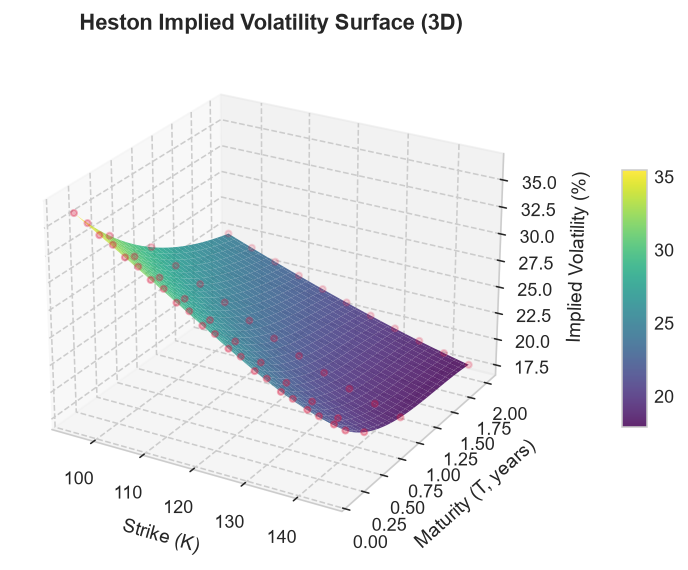

In [10]:
K_grid = np.linspace(95.0, 145.0, 11)
expiries = np.array([0.1, 0.25, 0.5, 1.0, 2.0])


iv_grid = np.zeros((len(expiries), len(K_grid)))
for i, mat in enumerate(expiries):
    calls = pricer.price_options_fast(S0, K_grid, mat, r, base_params, "call")
    iv_grid[i, :] = ImpliedVolatilitySolver.calculate_surface(calls, S0, K_grid, mat, r)

spline = RectBivariateSpline(expiries, K_grid, iv_grid)
T_dense = np.linspace(expiries.min(), expiries.max(), 60)
K_dense = np.linspace(K_grid.min(), K_grid.max(), 60)
T_mesh, K_mesh = np.meshgrid(T_dense, K_dense, indexing='ij')
iv_dense = spline(T_dense, K_dense)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(K_mesh, T_mesh, iv_dense * 100, cmap='viridis', edgecolor='none', alpha=0.85, antialiased=True)
T_orig, K_orig = np.meshgrid(expiries, K_grid, indexing='ij')
ax.scatter(K_orig, T_orig, iv_grid * 100, color='crimson', s=10, alpha=0.6)

ax.set_xlabel('Strike (K)')
ax.set_ylabel('Maturity (T, years)')
ax.set_zlabel('Implied Volatility (%)')
ax.set_title('Heston Implied Volatility Surface (3D)')
ax.view_init(elev=25, azim=-60)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
plt.tight_layout()
plt.show()


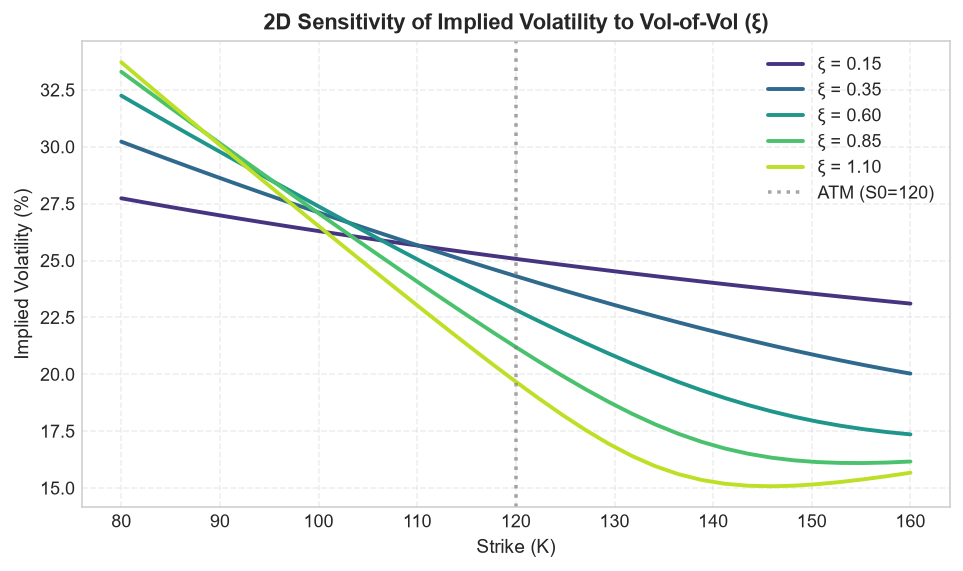

In [11]:
xi_values = [0.15, 0.35, 0.60, 0.85, 1.10]
K_sens = np.linspace(80, 160, 35)
T_val = 1.0

plt.figure()
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(xi_values)))

for xi_val, color in zip(xi_values, colors):
    p = HestonParameters(
        kappa=base_params.kappa,
        theta=base_params.theta,
        xi=xi_val,
        rho=base_params.rho,
        v_0=base_params.v_0
    )
    calls = pricer.price_options_fast(S0, K_sens, T_val, r, p, "call")
    ivs = ImpliedVolatilitySolver.calculate_surface(calls, S0, K_sens, T_val, r)
    plt.plot(K_sens, ivs * 100, label=f"ξ = {xi_val:.2f}", color=color, lw=2)

plt.axvline(S0, color='gray', linestyle=':', alpha=0.7, label=f"ATM (S0={S0:.0f})")
plt.xlabel("Strike (K)")
plt.ylabel("Implied Volatility (%)")
plt.title("2D Sensitivity of Implied Volatility to Vol-of-Vol (ξ)")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
import copy

target_params = copy.deepcopy(base_params)

market_data = []
rng = np.random.default_rng(42)

for T in expiries:
    moneyness_dist = np.abs(K_grid / S0 - 1.0)
    noise_std = 0.05 + 0.02 * moneyness_dist + 0.005 * (2.0 - T)
    
    calls_noise = rng.normal(loc=0.0, scale=noise_std)
    puts_noise = rng.normal(loc=0.0, scale=noise_std)
    
    calls = pricer.price_options_fast(S0, K_grid, T, r, target_params, "call")
    calls_noisy = calls + calls_noise
    
    calls_intrinsic = np.maximum(0.0, S0 - K_grid * np.exp(-r * T))
    calls_noisy = np.maximum(calls_noisy, calls_intrinsic + 0.01)
    
    puts = pricer.price_options_fast(S0, K_grid, T, r, target_params, "put")
    puts_noisy = puts + puts_noise
    
    puts_intrinsic = np.maximum(0.0, K_grid * np.exp(-r * T) - S0)
    puts_noisy = np.maximum(puts_noisy, puts_intrinsic + 0.01)

    market_data.append({
        "T": T,
        "r": r,
        "strikes": K_grid,
        "call_prices": calls_noisy,
        "put_prices": puts_noisy
    })
    
total_points = len(expiries) * len(K_grid) * 2
print(f"# of Mat {len(expiries)} x # of Strikes {len(K_grid)} = Total of {total_points} DPs")

# of Mat 5 x # of Strikes 11 = Total of 110 DPs


In [13]:
calib_quotes = []
for d in market_data:
    calib_quotes.append({
        "T": d["T"], "r": d["r"], "strikes": d["strikes"], 
        "market_prices": d["call_prices"], "option_type": "call"
    })
    calib_quotes.append({
        "T": d["T"], "r": d["r"], "strikes": d["strikes"], 
        "market_prices": d["put_prices"], "option_type": "put"
    })

config = HestonCalibrationConfig(
    seed=42, 
    maxiter_global=50,   # Change
    loss_type="msre"     # msre for OTM
)

calibrator = HestonCalibrator(pricer)
opt_params, diagnostics = calibrator.calibrate(S0, calib_quotes, config=config)

print("---------- Calibration Diagnostics ----------")

status = 'Success' if diagnostics.get('Local Success', False) else 'Failed'
print(f"Status : {status}")

for key, value in diagnostics.items():
    if isinstance(value, (float, np.floating)):
        print(f"{key:30s} : {value:.6f}")
    else:
        print(f"{key:30s} : {value}")
print("-" * 35)

df_calib = pd.DataFrame({
    "Target": [target_params.kappa, target_params.theta, target_params.xi, target_params.rho, target_params.v_0],
    "Calibrated": [opt_params.kappa, opt_params.theta, opt_params.xi, opt_params.rho, opt_params.v_0]
}, index=["kappa", "theta", "xi", "rho", "v_0"])

df_calib["Error (%)"] = ((df_calib["Calibrated"] - df_calib["Target"]) / df_calib["Target"].replace(0, 1e-9)).abs() * 100

display(df_calib.round(4))

---------- Calibration Diagnostics ----------
Status : Success
Elapsed Time (s)               : 1.840000
RMSE                           : 0.315736
MAE                            : 0.212636
MAPE (%)                       : 5.726984
Max Abs Error                  : 0.826093
Objective                      : 0.018309
Feller Ratio                   : 0.562715
Feller Satisfied               : False
Global Success                 : True
Global Message                 : Optimization terminated successfully.
Local Success                  : True
Local Message                  : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Optimizer Function Evaluations : 108
-----------------------------------


,Target,Calibrated,Error (%)
kappa,1.70,2.2509,32.4061
theta,0.04,0.0491,22.8486
xi,0.60,0.6270,4.4992
rho,-0.70,-0.8170,16.7196
v_0,0.09,0.0875,2.7430


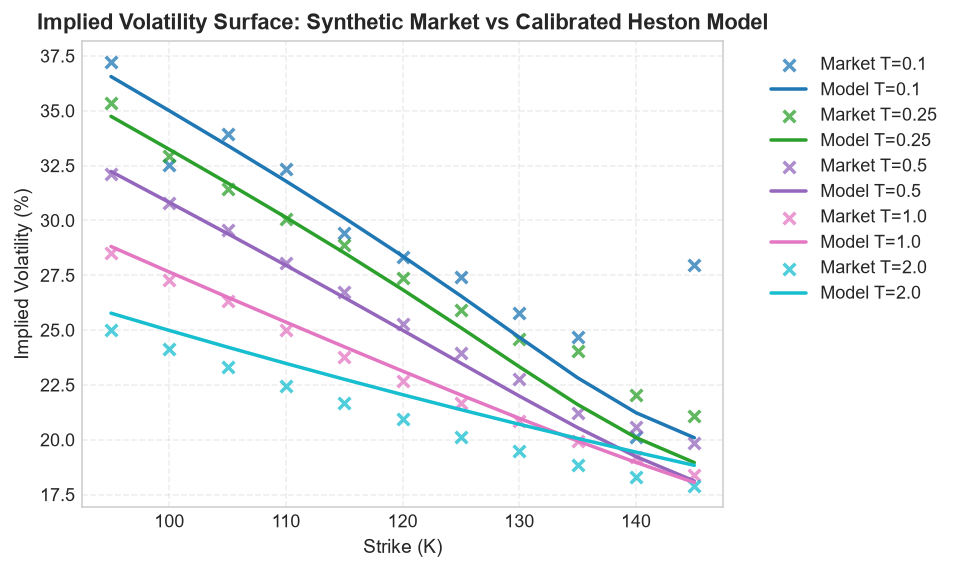

In [14]:
iv_mkt = []
iv_mod = []

for quote in market_data:
    strikes = quote["strikes"]
    T = quote["T"]
    r_rate = quote["r"]
    
    iv_m = ImpliedVolatilitySolver.calculate_surface(
        quote["call_prices"], S0, strikes, T, r_rate
    )
    iv_mkt.append(iv_m)
    
    mod_prices = pricer.price_options_fast(
        S0, strikes, T, r_rate, opt_params, "call"
    )
    iv_md = ImpliedVolatilitySolver.calculate_surface(
        mod_prices, S0, strikes, T, r_rate
    )
    iv_mod.append(iv_md)

plt.figure()

num_expiries = len(market_data)
colors = plt.cm.tab10(np.linspace(0, 0.9, num_expiries))

for i, quote in enumerate(market_data):
    T = quote["T"]
    strikes = quote["strikes"]
    color = colors[i]
    
    plt.scatter(strikes, iv_mkt[i] * 100, color=color, marker='x', alpha=0.75, label=f'Market T={T}')
    plt.plot(strikes, iv_mod[i] * 100, color=color, lw=1.8, label=f'Model T={T}')

plt.title("Implied Volatility Surface: Synthetic Market vs Calibrated Heston Model")
plt.xlabel("Strike (K)")
plt.ylabel("Implied Volatility (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Target Parameters (Greeks) 
 
 
 
 
 Price 
 Delta 
 Gamma 
 Vega 
 Theta 
 
 
 T 
 K 
 
 
 
 
 
 
 
 
 
 0.5 
 100.0 
 23.4321 
 0.8867 
 0.0060 
 22.2268 
 -0.0169 
 
 
 120.0 
 9.1034 
 0.6487 
 0.0177 
 42.0944 
 -0.0201 
 
 
 140.0 
 1.6081 
 0.2209 
 0.0225 
 29.0674 
 -0.0107 
 
 
 1.0 
 100.0 
 25.9297 
 0.8737 
 0.0052 
 27.2177 
 -0.0115 
 
 
 120.0 
 12.0277 
 0.6807 
 0.0137 
 43.4019 
 -0.0136 
 
 
 140.0 
 3.4887 
 0.3391 
 0.0212 
 38.3023 
 -0.0101 
 
 
 
 Optimized Parameters (Greeks) 
 
 
 
 
 Price 
 Delta 
 Gamma 
 Vega 
 Theta 
 
 
 T 
 K 
 
 
 
 
 
 
 
 
 
 0.5 
 100.0 
 23.4502 
 0.8881 
 0.0058 
 20.1911 
 -0.0169 
 
 
 120.0 
 9.0185 
 0.6581 
 0.0170 
 37.5002 
 -0.0208 
 
 
 140.0 
 1.3007 
 0.2201 
 0.0255 
 25.4756 
 -0.0108 
 
 
 1.0 
 100.0 
 26.0172 
 0.8710 
 0.0053 
 22.6240 
 -0.0122 
 
 
 120.0 
 12.1688 
 0.6832 
 0.0129 
 35.1793 
 -0.0151 
 
 
 140.0 
 3.4269 
 0.3582 
 0.0212 
 32.0302 
 -0.0121 
 
 
 
 
 
 Target Parameters (PnL Attribution) 
 
 
 
 
 Actual 
 Delta 
 Gamma 
 Vega 
 Theta 
 Residual 
 
 
 T 
 K 
 
 
 
 
 
 
 
 
 
 
 0.5 
 100.0 
 1.5256 
 1.5960 
 0.0097 
 -0.0667 
 -0.0169 
 0.0035 
 
 
 120.0 
 1.0497 
 1.1677 
 0.0286 
 -0.1263 
 -0.0201 
 -0.0003 
 
 
 140.0 
 0.3237 
 0.3976 
 0.0365 
 -0.0872 
 -0.0107 
 -0.0124 
 
 
 1.0 
 100.0 
 1.4904 
 1.5727 
 0.0085 
 -0.0817 
 -0.0115 
 0.0024 
 
 
 120.0 
 1.1032 
 1.2252 
 0.0221 
 -0.1302 
 -0.0136 
 -0.0003 
 
 
 140.0 
 0.5103 
 0.6104 
 0.0343 
 -0.1149 
 -0.0101 
 -0.0094 
 
 
 
 Optimized Parameters (PnL Attribution) 
 
 
 
 
 Actual 
 Delta 
 Gamma 
 Vega 
 Theta 
 Residual 
 
 
 T 
 K 
 
 
 
 
 
 
 
 
 
 
 0.5 
 100.0 
 1.5336 
 1.5987 
 0.0094 
 -0.0606 
 -0.0169 
 0.0030 
 
 
 120.0 
 1.0787 
 1.1846 
 0.0276 
 -0.1125 
 -0.0208 
 -0.0003 
 
 
 140.0 
 0.3374 
 0.3961 
 0.0413 
 -0.0764 
 -0.0108 
 -0.0128 
 
 
 1.0 
 100.0 
 1.4982 
 1.5679 
 0.0085 
 -0.0679 
 -0.0122 
 0.0018 
 
 
 120.0 
 1.1297 
 1.2298 
 0.0209 
 -0.1055 
 -0.0151 
 -0.0004 
 
 
 140.0 
 0.5632 
 0.6448 
 0.0343 
 -0.0961 
 -0.0121 
 -0.0077

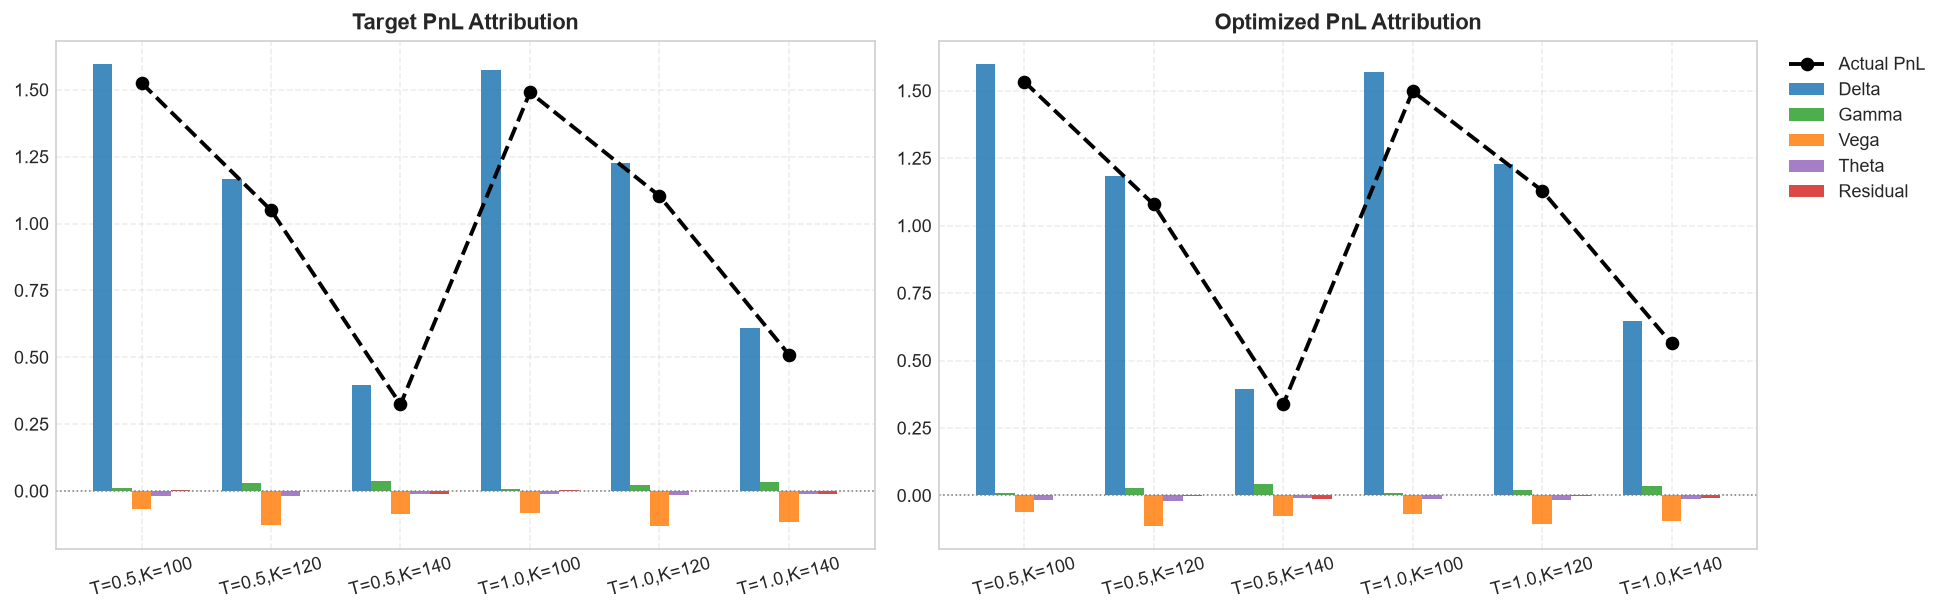

In [15]:
T_rep = [0.5, 1.0]
K_rep = [100.0, 120.0, 140.0]
q_div = 0.0

days = 1.0
dt = days / 365.0
dS = S0 * 0.015
dv = -0.003

tgt_shock = HestonParameters(
    kappa=target_params.kappa, theta=target_params.theta,
    xi=target_params.xi, rho=target_params.rho, v_0=max(1e-4, target_params.v_0 + dv)
)
opt_shock = HestonParameters(
    kappa=opt_params.kappa, theta=opt_params.theta,
    xi=opt_params.xi, rho=opt_params.rho, v_0=max(1e-4, opt_params.v_0 + dv)
)

recs_g_tgt, recs_g_cal = [], []
recs_p_tgt, recs_p_cal = [], []

for T in T_rep:
    g_tgt = pricer.price_and_greeks_fast(S0, np.array(K_rep), T, r, target_params, "call", q=q_div)
    g_cal = pricer.price_and_greeks_fast(S0, np.array(K_rep), T, r, opt_params, "call", q=q_div)
    
    g_tgt_shk = pricer.price_and_greeks_fast(S0 + dS, np.array(K_rep), max(1e-4, T - dt), r, tgt_shock, "call", q=q_div)
    g_cal_shk = pricer.price_and_greeks_fast(S0 + dS, np.array(K_rep), max(1e-4, T - dt), r, opt_shock, "call", q=q_div)
    
    for i, K in enumerate(K_rep):
        recs_g_tgt.append({"T": T, "K": K, "Price": g_tgt.price[i], "Delta": g_tgt.delta[i], "Gamma": g_tgt.gamma[i], "Vega": g_tgt.vega[i], "Theta": g_tgt.theta[i]})
        recs_g_cal.append({"T": T, "K": K, "Price": g_cal.price[i], "Delta": g_cal.delta[i], "Gamma": g_cal.gamma[i], "Vega": g_cal.vega[i], "Theta": g_cal.theta[i]})
        
        act_t = g_tgt_shk.price[i] - g_tgt.price[i]
        d_t = g_tgt.delta[i] * dS; g_t = 0.5 * g_tgt.gamma[i] * (dS**2); v_t = g_tgt.vega[i] * dv; th_t = g_tgt.theta[i] * days
        recs_p_tgt.append({"T": T, "K": K, "Actual": act_t, "Delta": d_t, "Gamma": g_t, "Vega": v_t, "Theta": th_t, "Residual": act_t - (d_t + g_t + v_t + th_t)})
        
        act_c = g_cal_shk.price[i] - g_cal.price[i]
        d_c = g_cal.delta[i] * dS; g_c = 0.5 * g_cal.gamma[i] * (dS**2); v_c = g_cal.vega[i] * dv; th_c = g_cal.theta[i] * days
        recs_p_cal.append({"T": T, "K": K, "Actual": act_c, "Delta": d_c, "Gamma": g_c, "Vega": v_c, "Theta": th_c, "Residual": act_c - (d_c + g_c + v_c + th_c)})

df_g_tgt = pd.DataFrame(recs_g_tgt).set_index(["T", "K"]).round(4)
df_g_cal = pd.DataFrame(recs_g_cal).set_index(["T", "K"]).round(4)
df_p_tgt = pd.DataFrame(recs_p_tgt).set_index(["T", "K"]).round(4)
df_p_cal = pd.DataFrame(recs_p_cal).set_index(["T", "K"]).round(4)

display_html(f"""
<div style="display:flex; justify-content:space-around;">
    <div><h4>Target Parameters (Greeks)</h4>{df_g_tgt.to_html()}</div>
    <div><h4>Optimized Parameters (Greeks)</h4>{df_g_cal.to_html()}</div>
</div><br>
<div style="display:flex; justify-content:space-around;">
    <div><h4>Target Parameters (PnL Attribution)</h4>{df_p_tgt.to_html()}</div>
    <div><h4>Optimized Parameters (PnL Attribution)</h4>{df_p_cal.to_html()}</div>
</div>
""", raw=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
labels = [f"T={r['T']},K={r['K']:.0f}" for r in recs_p_tgt]
x = np.arange(len(labels))
width = 0.15

for ax, title, recs in zip(axes, ["Target PnL Attribution", "Optimized PnL Attribution"], [recs_p_tgt, recs_p_cal]):
    ax.bar(x - 2*width, [r["Delta"] for r in recs], width, label='Delta', color='#1f77b4', alpha=0.85)
    ax.bar(x - width, [r["Gamma"] for r in recs], width, label='Gamma', color='#2ca02c', alpha=0.85)
    ax.bar(x, [r["Vega"] for r in recs], width, label='Vega', color='#ff7f0e', alpha=0.85)
    ax.bar(x + width, [r["Theta"] for r in recs], width, label='Theta', color='#9467bd', alpha=0.85)
    ax.bar(x + 2*width, [r["Residual"] for r in recs], width, label='Residual', color='#d62728', alpha=0.85)
    ax.plot(x, [r["Actual"] for r in recs], 'ko--', lw=2, label='Actual PnL')
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_title(title, fontweight='bold')
    ax.axhline(0, color='gray', linestyle=':', lw=0.8)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
# Another calibration Example

rng = np.random.default_rng(42)

S0 = 120.0
r = 0.02
target_params = base_params  # kappa=1.70, theta=0.04, xi=0.60, rho=-0.70, v_0=0.09

expiries = [0.25, 0.5, 1.0, 1.5, 2.0]
moneyness_grid = np.array([0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.3])
K_grid = S0 * moneyness_grid

relative_noise_std = 0.03

market_data = []

for T in expiries:
    calls = pricer.price_options_fast(S0, K_grid, T, r, target_params, "call")
    puts = pricer.price_options_fast(S0, K_grid, T, r, target_params, "put")

    calls_noise_factor = rng.normal(loc=1.0, scale=relative_noise_std, size=len(K_grid))
    puts_noise_factor = rng.normal(loc=1.0, scale=relative_noise_std, size=len(K_grid))

    calls_noisy = calls * calls_noise_factor
    puts_noisy = puts * puts_noise_factor

    calls_intrinsic = np.maximum(0.0, S0 - K_grid * np.exp(-r * T))
    puts_intrinsic = np.maximum(0.0, K_grid * np.exp(-r * T) - S0)

    calls_noisy = np.maximum(calls_noisy, calls_intrinsic + 0.01)
    puts_noisy = np.maximum(puts_noisy, puts_intrinsic + 0.01)

    market_data.append({
        "T": T,
        "r": r,
        "strikes": K_grid,
        "call_prices": calls_noisy,
        "put_prices": puts_noisy
    })
    
total_points = len(expiries) * len(K_grid) * 2
print(f"# of Mat {len(expiries)} x # of Strikes {len(K_grid)} = Total of {total_points} DPs")

# of Mat 5 x # of Strikes 9 = Total of 90 DPs


In [17]:
calib_quotes = []
for d in market_data:
    calib_quotes.append({
        "T": d["T"], "r": d["r"], "strikes": d["strikes"], 
        "market_prices": d["call_prices"], "option_type": "call"
    })
    calib_quotes.append({
        "T": d["T"], "r": d["r"], "strikes": d["strikes"], 
        "market_prices": d["put_prices"], "option_type": "put"
    })

config = HestonCalibrationConfig(
    seed=42, 
    maxiter_global=50,   # Change
    loss_type="msre"     # msre for OTM
)

calibrator = HestonCalibrator(pricer)
opt_params, diagnostics = calibrator.calibrate(S0, calib_quotes, config=config)

print("---------- Calibration Diagnostics ----------")

status = 'Success' if diagnostics.get('Local Success', False) else 'Failed'
print(f"Status : {status}")

for key, value in diagnostics.items():
    if isinstance(value, (float, np.floating)):
        print(f"{key:30s} : {value:.6f}")
    else:
        print(f"{key:30s} : {value}")
print("-" * 35)

df_calib = pd.DataFrame({
    "Target": [target_params.kappa, target_params.theta, target_params.xi, target_params.rho, target_params.v_0],
    "Calibrated": [opt_params.kappa, opt_params.theta, opt_params.xi, opt_params.rho, opt_params.v_0]
}, index=["kappa", "theta", "xi", "rho", "v_0"])

df_calib["Error (%)"] = ((df_calib["Calibrated"] - df_calib["Target"]) / df_calib["Target"].replace(0, 1e-9)).abs() * 100

display(df_calib.round(4))

---------- Calibration Diagnostics ----------
Status : Success
Elapsed Time (s)               : 2.820000
RMSE                           : 0.383019
MAE                            : 0.254521
MAPE (%)                       : 1.808661
Max Abs Error                  : 1.184520
Objective                      : 0.000494
Feller Ratio                   : 0.369197
Feller Satisfied               : False
Global Success                 : True
Global Message                 : Optimization terminated successfully.
Local Success                  : True
Local Message                  : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Optimizer Function Evaluations : 102
-----------------------------------


,Target,Calibrated,Error (%)
kappa,1.70,1.6628,2.1896
theta,0.04,0.0401,0.3640
xi,0.60,0.6013,0.2238
rho,-0.70,-0.6990,0.1375
v_0,0.09,0.0897,0.3454


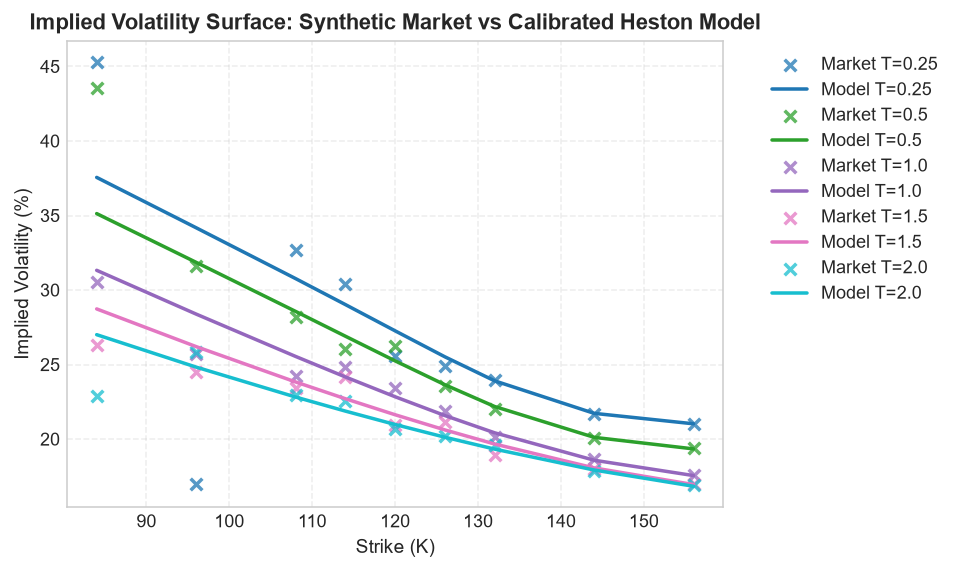

In [18]:
iv_mkt = []
iv_mod = []

for quote in market_data:
    strikes = quote["strikes"]
    T = quote["T"]
    r_rate = quote["r"]
    
    iv_m = ImpliedVolatilitySolver.calculate_surface(
        quote["call_prices"], S0, strikes, T, r_rate
    )
    iv_mkt.append(iv_m)
    
    mod_prices = pricer.price_options_fast(
        S0, strikes, T, r_rate, opt_params, "call"
    )
    iv_md = ImpliedVolatilitySolver.calculate_surface(
        mod_prices, S0, strikes, T, r_rate
    )
    iv_mod.append(iv_md)

plt.figure()

num_expiries = len(market_data)
colors = plt.cm.tab10(np.linspace(0, 0.9, num_expiries))

for i, quote in enumerate(market_data):
    T = quote["T"]
    strikes = quote["strikes"]
    color = colors[i]
    
    plt.scatter(strikes, iv_mkt[i] * 100, color=color, marker='x', alpha=0.75, label=f'Market T={T}')
    plt.plot(strikes, iv_mod[i] * 100, color=color, lw=1.8, label=f'Model T={T}')

plt.title("Implied Volatility Surface: Synthetic Market vs Calibrated Heston Model")
plt.xlabel("Strike (K)")
plt.ylabel("Implied Volatility (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Target Parameters (Greeks) 
 
 
 
 
 Price 
 Delta 
 Gamma 
 Vega 
 Theta 
 
 
 T 
 K 
 
 
 
 
 
 
 
 
 
 0.5 
 100.0 
 23.4321 
 0.8867 
 0.0060 
 22.2268 
 -0.0169 
 
 
 120.0 
 9.1034 
 0.6487 
 0.0177 
 42.0944 
 -0.0201 
 
 
 140.0 
 1.6081 
 0.2209 
 0.0225 
 29.0674 
 -0.0107 
 
 
 1.0 
 100.0 
 25.9297 
 0.8737 
 0.0052 
 27.2177 
 -0.0115 
 
 
 120.0 
 12.0277 
 0.6807 
 0.0137 
 43.4019 
 -0.0136 
 
 
 140.0 
 3.4887 
 0.3391 
 0.0212 
 38.3023 
 -0.0101 
 
 
 
 Optimized Parameters (Greeks) 
 
 
 
 
 Price 
 Delta 
 Gamma 
 Vega 
 Theta 
 
 
 T 
 K 
 
 
 
 
 
 
 
 
 
 0.5 
 100.0 
 23.4378 
 0.8868 
 0.0060 
 22.3924 
 -0.0170 
 
 
 120.0 
 9.1026 
 0.6492 
 0.0177 
 42.4220 
 -0.0201 
 
 
 140.0 
 1.6053 
 0.2204 
 0.0225 
 29.2152 
 -0.0107 
 
 
 1.0 
 100.0 
 25.9441 
 0.8740 
 0.0052 
 27.5447 
 -0.0115 
 
 
 120.0 
 12.0309 
 0.6815 
 0.0137 
 43.9144 
 -0.0136 
 
 
 140.0 
 3.4831 
 0.3388 
 0.0213 
 38.6893 
 -0.0101 
 
 
 
 
 
 Target Parameters (PnL Attribution) 
 
 
 
 
 Actual 
 Delta 
 Gamma 
 Vega 
 Theta 
 Residual 
 
 
 T 
 K 
 
 
 
 
 
 
 
 
 
 
 0.5 
 100.0 
 1.5256 
 1.5960 
 0.0097 
 -0.0667 
 -0.0169 
 0.0035 
 
 
 120.0 
 1.0497 
 1.1677 
 0.0286 
 -0.1263 
 -0.0201 
 -0.0003 
 
 
 140.0 
 0.3237 
 0.3976 
 0.0365 
 -0.0872 
 -0.0107 
 -0.0124 
 
 
 1.0 
 100.0 
 1.4904 
 1.5727 
 0.0085 
 -0.0817 
 -0.0115 
 0.0024 
 
 
 120.0 
 1.1032 
 1.2252 
 0.0221 
 -0.1302 
 -0.0136 
 -0.0003 
 
 
 140.0 
 0.5103 
 0.6104 
 0.0343 
 -0.1149 
 -0.0101 
 -0.0094 
 
 
 
 Optimized Parameters (PnL Attribution) 
 
 
 
 
 Actual 
 Delta 
 Gamma 
 Vega 
 Theta 
 Residual 
 
 
 T 
 K 
 
 
 
 
 
 
 
 
 
 
 0.5 
 100.0 
 1.5252 
 1.5962 
 0.0097 
 -0.0672 
 -0.0170 
 0.0035 
 
 
 120.0 
 1.0496 
 1.1686 
 0.0286 
 -0.1273 
 -0.0201 
 -0.0002 
 
 
 140.0 
 0.3223 
 0.3966 
 0.0365 
 -0.0876 
 -0.0107 
 -0.0125 
 
 
 1.0 
 100.0 
 1.4899 
 1.5732 
 0.0085 
 -0.0826 
 -0.0115 
 0.0024 
 
 
 120.0 
 1.1032 
 1.2268 
 0.0221 
 -0.1317 
 -0.0136 
 -0.0003 
 
 
 140.0 
 0.5087 
 0.6099 
 0.0345 
 -0.1161 
 -0.0101 
 -0.0095

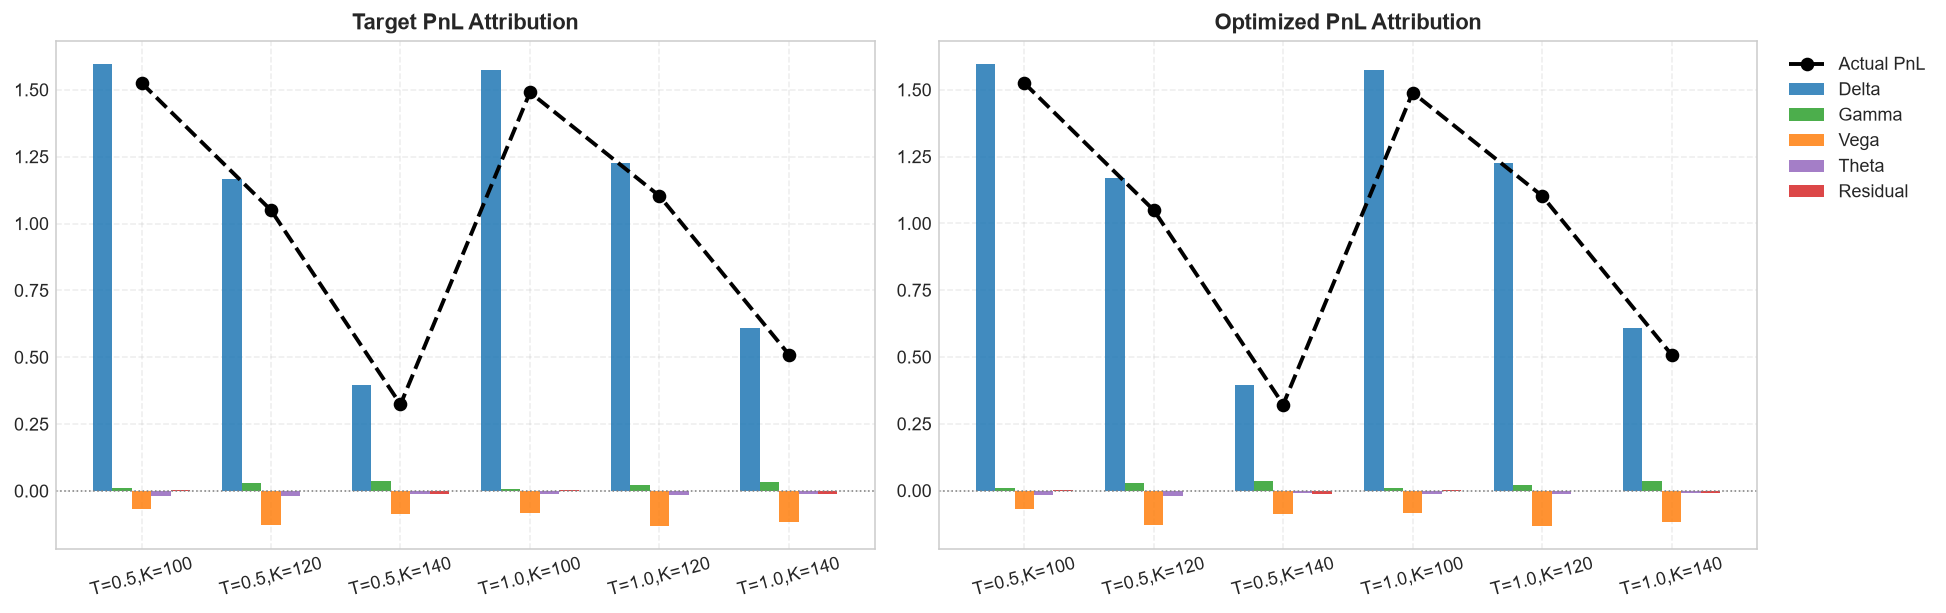

In [19]:
T_rep = [0.5, 1.0]
K_rep = [100.0, 120.0, 140.0]
q_div = 0.0

days = 1.0
dt = days / 365.0
dS = S0 * 0.015
dv = -0.003

tgt_shock = HestonParameters(
    kappa=target_params.kappa, theta=target_params.theta,
    xi=target_params.xi, rho=target_params.rho, v_0=max(1e-4, target_params.v_0 + dv)
)
opt_shock = HestonParameters(
    kappa=opt_params.kappa, theta=opt_params.theta,
    xi=opt_params.xi, rho=opt_params.rho, v_0=max(1e-4, opt_params.v_0 + dv)
)

recs_g_tgt, recs_g_cal = [], []
recs_p_tgt, recs_p_cal = [], []

for T in T_rep:
    g_tgt = pricer.price_and_greeks_fast(S0, np.array(K_rep), T, r, target_params, "call", q=q_div)
    g_cal = pricer.price_and_greeks_fast(S0, np.array(K_rep), T, r, opt_params, "call", q=q_div)
    
    g_tgt_shk = pricer.price_and_greeks_fast(S0 + dS, np.array(K_rep), max(1e-4, T - dt), r, tgt_shock, "call", q=q_div)
    g_cal_shk = pricer.price_and_greeks_fast(S0 + dS, np.array(K_rep), max(1e-4, T - dt), r, opt_shock, "call", q=q_div)
    
    for i, K in enumerate(K_rep):
        recs_g_tgt.append({"T": T, "K": K, "Price": g_tgt.price[i], "Delta": g_tgt.delta[i], "Gamma": g_tgt.gamma[i], "Vega": g_tgt.vega[i], "Theta": g_tgt.theta[i]})
        recs_g_cal.append({"T": T, "K": K, "Price": g_cal.price[i], "Delta": g_cal.delta[i], "Gamma": g_cal.gamma[i], "Vega": g_cal.vega[i], "Theta": g_cal.theta[i]})
        
        act_t = g_tgt_shk.price[i] - g_tgt.price[i]
        d_t = g_tgt.delta[i] * dS; g_t = 0.5 * g_tgt.gamma[i] * (dS**2); v_t = g_tgt.vega[i] * dv; th_t = g_tgt.theta[i] * days
        recs_p_tgt.append({"T": T, "K": K, "Actual": act_t, "Delta": d_t, "Gamma": g_t, "Vega": v_t, "Theta": th_t, "Residual": act_t - (d_t + g_t + v_t + th_t)})
        
        act_c = g_cal_shk.price[i] - g_cal.price[i]
        d_c = g_cal.delta[i] * dS; g_c = 0.5 * g_cal.gamma[i] * (dS**2); v_c = g_cal.vega[i] * dv; th_c = g_cal.theta[i] * days
        recs_p_cal.append({"T": T, "K": K, "Actual": act_c, "Delta": d_c, "Gamma": g_c, "Vega": v_c, "Theta": th_c, "Residual": act_c - (d_c + g_c + v_c + th_c)})

df_g_tgt = pd.DataFrame(recs_g_tgt).set_index(["T", "K"]).round(4)
df_g_cal = pd.DataFrame(recs_g_cal).set_index(["T", "K"]).round(4)
df_p_tgt = pd.DataFrame(recs_p_tgt).set_index(["T", "K"]).round(4)
df_p_cal = pd.DataFrame(recs_p_cal).set_index(["T", "K"]).round(4)

display_html(f"""
<div style="display:flex; justify-content:space-around;">
    <div><h4>Target Parameters (Greeks)</h4>{df_g_tgt.to_html()}</div>
    <div><h4>Optimized Parameters (Greeks)</h4>{df_g_cal.to_html()}</div>
</div><br>
<div style="display:flex; justify-content:space-around;">
    <div><h4>Target Parameters (PnL Attribution)</h4>{df_p_tgt.to_html()}</div>
    <div><h4>Optimized Parameters (PnL Attribution)</h4>{df_p_cal.to_html()}</div>
</div>
""", raw=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
labels = [f"T={r['T']},K={r['K']:.0f}" for r in recs_p_tgt]
x = np.arange(len(labels))
width = 0.15

for ax, title, recs in zip(axes, ["Target PnL Attribution", "Optimized PnL Attribution"], [recs_p_tgt, recs_p_cal]):
    ax.bar(x - 2*width, [r["Delta"] for r in recs], width, label='Delta', color='#1f77b4', alpha=0.85)
    ax.bar(x - width, [r["Gamma"] for r in recs], width, label='Gamma', color='#2ca02c', alpha=0.85)
    ax.bar(x, [r["Vega"] for r in recs], width, label='Vega', color='#ff7f0e', alpha=0.85)
    ax.bar(x + width, [r["Theta"] for r in recs], width, label='Theta', color='#9467bd', alpha=0.85)
    ax.bar(x + 2*width, [r["Residual"] for r in recs], width, label='Residual', color='#d62728', alpha=0.85)
    ax.plot(x, [r["Actual"] for r in recs], 'ko--', lw=2, label='Actual PnL')
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_title(title, fontweight='bold')
    ax.axhline(0, color='gray', linestyle=':', lw=0.8)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()